# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Udaiveer Singh  
**`Roll Number`:** U20230017  
**`GitHub Branch`:** udaiveer_U20230017  

# Imports and Setup

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Load Datasets

In [28]:
train_users = pd.read_csv("data/train_users.csv")

print(train_users.head())
print(train_users.shape)

  user_id   age  income  clicks  purchase_amount  session_duration  \
0   U7392   NaN   23053      10           500.00             17.34   
1   U2702  56.0   20239      11           913.33             22.22   
2   U2461   NaN   13907       9          1252.62             41.57   
3   U7475   NaN   26615      12           500.00             30.17   
4   U6040  32.0   27958      13           500.00             65.27   

   content_variety  engagement_score  num_transactions  avg_monthly_spend  \
0          0.36661          37.29781                 3             187.44   
1          0.61370          59.36342                 5             145.15   
2          0.80368          76.78706                 7             282.03   
3          0.26499          30.19441                10             195.35   
4          0.36385          37.12153                 5             439.68   

   ...  screen_brightness  battery_percentage  cart_abandonment_count  \
0  ...                4.0                 2

In [29]:
train_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      2000 non-null   str    
 1   age                          1302 non-null   float64
 2   income                       2000 non-null   int64  
 3   clicks                       2000 non-null   int64  
 4   purchase_amount              2000 non-null   float64
 5   session_duration             2000 non-null   float64
 6   content_variety              2000 non-null   float64
 7   engagement_score             2000 non-null   float64
 8   num_transactions             2000 non-null   int64  
 9   avg_monthly_spend            2000 non-null   float64
 10  avg_cart_value               2000 non-null   float64
 11  browsing_depth               2000 non-null   int64  
 12  revisit_rate                 2000 non-null   float64
 13  scroll_activity              

In [30]:
train_users.describe(include="all")

,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
count,2000,1302.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.00000,2000,2000.000000,2000.000000,2000.000000,2000,2000,2000
unique,1804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1973,NaN,NaN,NaN,1284,2,3
top,U8400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.32.48,NaN,NaN,NaN,X123,False,user_2
freq,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2,NaN,NaN,NaN,150,1444,712
mean,NaN,39.227343,21564.393500,10.526000,854.920700,32.641035,0.491309,49.325532,6.019000,359.416645,...,3.057850,51.219000,5.05300,NaN,9.456500,15.091855,24.514500,NaN,NaN,NaN
std,NaN,11.407103,6740.282694,3.299207,833.770472,22.769625,0.244320,24.584840,2.561429,413.886399,...,1.102046,27.704671,2.28797,NaN,3.457034,8.547876,18.501836,NaN,NaN,NaN
min,NaN,18.000000,10000.000000,1.000000,500.000000,0.000000,0.005040,0.000000,1.000000,0.000000,...,1.200000,2.000000,0.00000,NaN,4.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,31.000000,16742.500000,8.000000,500.000000,10.987500,0.289365,31.912582,4.000000,150.147500,...,2.100000,28.000000,3.00000,NaN,6.000000,7.657500,10.000000,NaN,NaN,NaN
50%,NaN,39.000000,21107.500000,10.000000,500.000000,33.475000,0.493505,49.566750,6.000000,231.370000,...,3.100000,52.000000,5.00000,NaN,9.000000,15.420000,21.000000,NaN,NaN,NaN
75%,NaN,47.000000,25892.500000,13.000000,596.295000,48.732500,0.661632,64.603265,8.000000,393.437500,...,4.000000,74.000000,6.00000,NaN,12.000000,22.295000,35.000000,NaN,NaN,NaN


## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [31]:
print(train_users.isna().sum())

user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                  0
background_app_count             0
session_inactivity_d

In [32]:
# Handle missing values
train_users["age"] = train_users["age"].fillna(train_users["age"].median())

print(train_users.isna().sum())

user_id                        0
age                            0
income                         0
clicks                         0
purchase_amount                0
session_duration               0
content_variety                0
engagement_score               0
num_transactions               0
avg_monthly_spend              0
avg_cart_value                 0
browsing_depth                 0
revisit_rate                   0
scroll_activity                0
time_on_site                   0
interaction_count              0
preferred_price_range          0
discount_usage_rate            0
wishlist_size                  0
product_views                  0
repeat_purchase_gap (days)     0
churn_risk_score               0
loyalty_index                  0
screen_brightness              0
battery_percentage             0
cart_abandonment_count         0
browser_version                0
background_app_count           0
session_inactivity_duration    0
network_jitter                 0
region_cod

In [33]:
# Drop non-informative identifier
train_users = train_users.drop(columns=["user_id"])

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [34]:
X = train_users.drop(columns=["label"])
y = train_users["label"]

print(X.shape, y.shape)

(2000, 31) (2000,)


In [35]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['user_1' 'user_2' 'user_3']


In [36]:
cat_cols = X.select_dtypes(include=["object", "bool"]).columns
cat_cols

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20904\1651384793.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "bool"]).columns


Index(['browser_version', 'region_code', 'subscriber'], dtype='str')

In [37]:
X_encoded = X.copy()

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [39]:
# Store encoders for reuse in inference
feature_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    feature_encoders[col] = le

In [40]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

c:\Users\LENOVO\anaconda3\envs\rlcmab\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
from sklearn.metrics import accuracy_score, classification_report

y_val_pred = clf.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=label_encoder.classes_
    )
)

Validation Accuracy: 0.8275
              precision    recall  f1-score   support

      user_1       0.86      0.80      0.83       142
      user_2       0.94      0.80      0.86       142
      user_3       0.71      0.90      0.79       116

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [42]:
from rlcmab_sampler import sampler

reward_sampler = sampler(17)

## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [43]:
news_categories = ["Entertainment", "Education", "Tech", "Crime"]

def arm_index(user_context_idx, news_idx):
    return user_context_idx * 4 + news_idx

In [44]:
# Constants
USER_CLASSES = ["user_1", "user_2", "user_3"]
NEWS_CATEGORIES = ["Entertainment", "Education", "Tech", "Crime"]

NUM_CONTEXTS = 3
NUM_ARMS_PER_CONTEXT = 4
TOTAL_ARMS = 12

In [45]:
def get_arm_index(user_context, news_category):
    """
    Maps (user_context, news_category) -> arm index j
    """
    context_idx = USER_CLASSES.index(user_context)
    category_idx = NEWS_CATEGORIES.index(news_category)
    return context_idx * NUM_ARMS_PER_CONTEXT + category_idx

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [46]:
def initialize_bandit():
    return {
        "counts": np.zeros(NUM_ARMS_PER_CONTEXT),
        "values": np.zeros(NUM_ARMS_PER_CONTEXT)
    }

# One bandit per context
epsilon_bandits = {
    user: initialize_bandit() for user in USER_CLASSES
}

In [47]:
import random

def epsilon_greedy_select(bandit, epsilon):
    if random.random() < epsilon:
        # Exploration
        return random.randint(0, NUM_ARMS_PER_CONTEXT - 1)
    else:
        # Exploitation
        return np.argmax(bandit["values"])

In [48]:
def update_estimates(bandit, arm, reward):
    bandit["counts"][arm] += 1
    n = bandit["counts"][arm]
    value = bandit["values"][arm]
    
    # Incremental mean update
    bandit["values"][arm] = value + (reward - value) / n

In [49]:
def run_epsilon_greedy(epsilon, T=10000):
    bandits = {user: initialize_bandit() for user in USER_CLASSES}
    rewards_over_time = {user: [] for user in USER_CLASSES}
    
    for t in range(T):
        # Randomly sample a context (simulated environment)
        user_context = random.choice(USER_CLASSES)
        bandit = bandits[user_context]
        
        # Choose arm
        arm_local = epsilon_greedy_select(bandit, epsilon)
        
        # Convert to global arm index
        arm_global = USER_CLASSES.index(user_context) * NUM_ARMS_PER_CONTEXT + arm_local
        
        # Sample reward
        reward = reward_sampler.sample(arm_global)
        
        # Update estimates
        update_estimates(bandit, arm_local, reward)
        
        # Log reward
        rewards_over_time[user_context].append(reward)
    
    return rewards_over_time, bandits

In [50]:
epsilons = [0.05, 0.1, 0.2]
epsilon_results = {}

for eps in epsilons:
    rewards, _ = run_epsilon_greedy(eps)
    epsilon_results[eps] = rewards
    
def plot_avg_reward(reward_dict, title):
    plt.figure(figsize=(10,6))
    
    for user, rewards in reward_dict.items():
        avg_rewards = np.cumsum(rewards) / np.arange(1, len(rewards)+1)
        plt.plot(avg_rewards, label=user)
    
    plt.xlabel("Time Steps")
    plt.ylabel("Average Reward")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

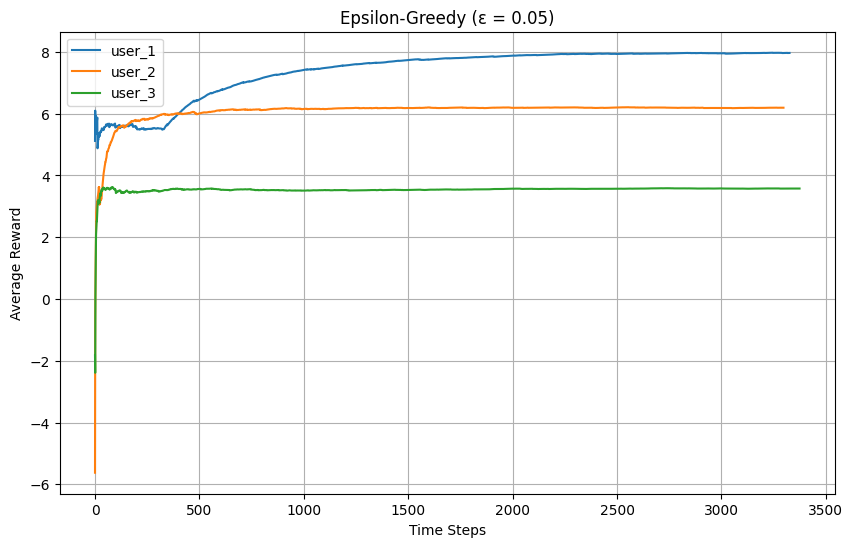

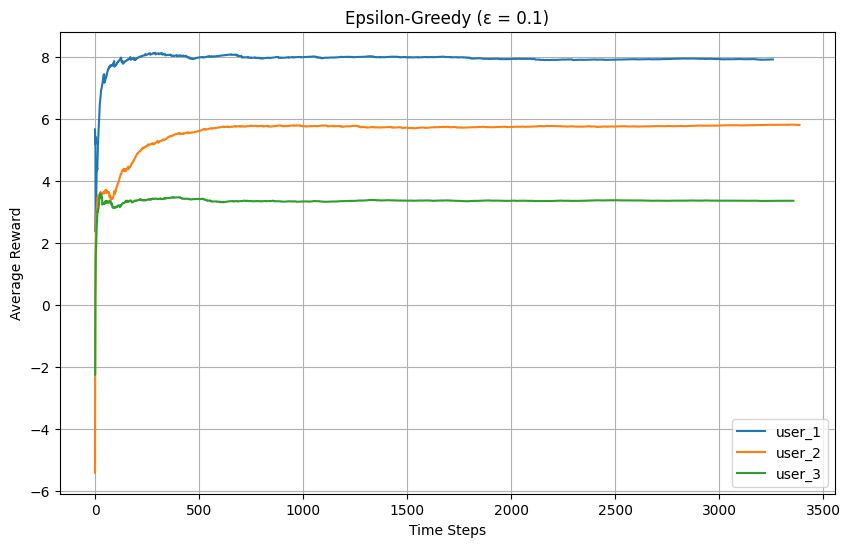

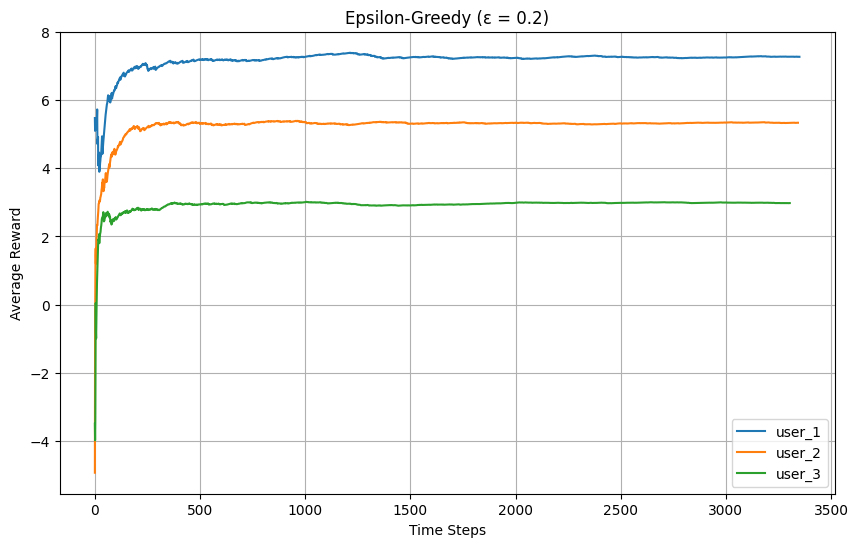

In [51]:
for eps in epsilons:
    plot_avg_reward(
        epsilon_results[eps],
        title=f"Epsilon-Greedy (ε = {eps})"
    )

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [52]:
import math

def ucb_select(bandit, t, C):
    """
    Selects arm using Upper Confidence Bound
    """
    counts = bandit["counts"]
    values = bandit["values"]
    
    # Ensure each arm is tried at least once
    for arm in range(NUM_ARMS_PER_CONTEXT):
        if counts[arm] == 0:
            return arm
    
    ucb_scores = values + C * np.sqrt(np.log(t) / counts)
    return np.argmax(ucb_scores)

In [53]:
def run_ucb(C, T=10000):
    bandits = {user: initialize_bandit() for user in USER_CLASSES}
    rewards_over_time = {user: [] for user in USER_CLASSES}
    
    for t in range(1, T + 1):
        # Sample a user context
        user_context = random.choice(USER_CLASSES)
        bandit = bandits[user_context]
        
        # Select arm using UCB
        arm_local = ucb_select(bandit, t, C)
        
        # Global arm index
        arm_global = USER_CLASSES.index(user_context) * NUM_ARMS_PER_CONTEXT + arm_local
        
        # Get reward
        reward = reward_sampler.sample(arm_global)
        
        # Update estimates
        update_estimates(bandit, arm_local, reward)
        
        # Log reward
        rewards_over_time[user_context].append(reward)
    
    return rewards_over_time, bandits

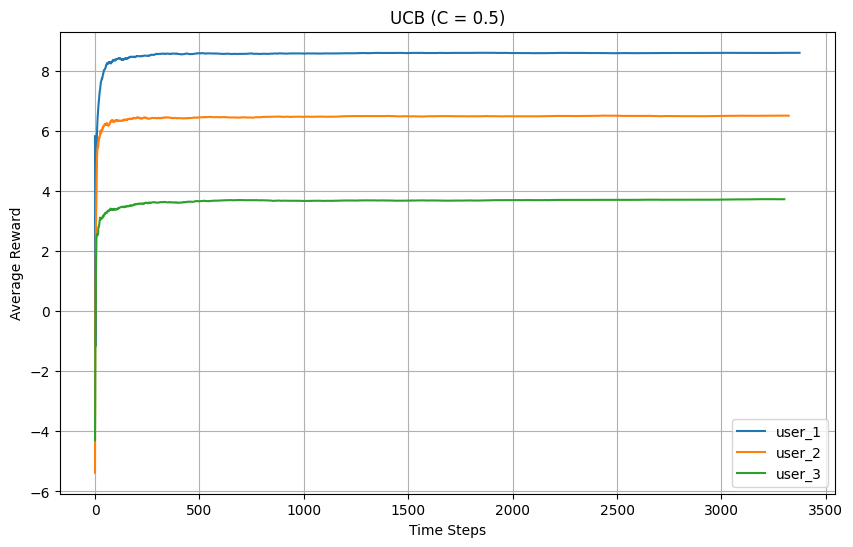

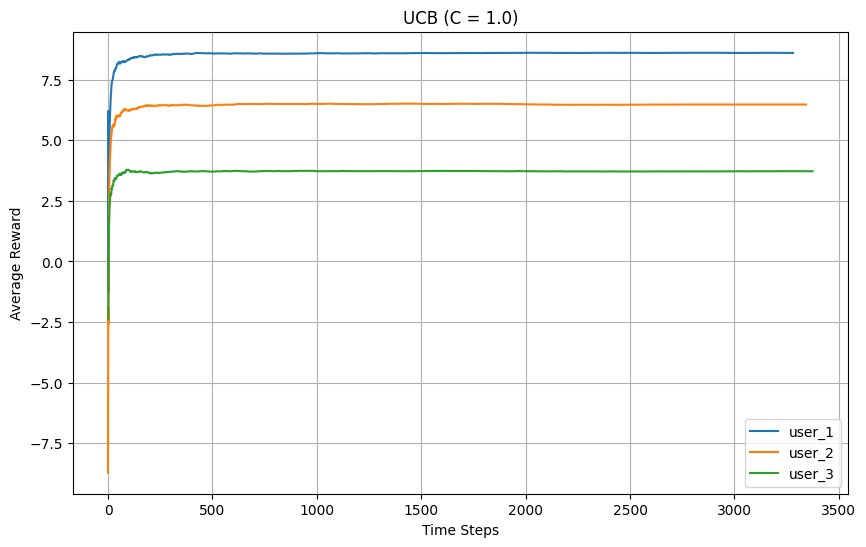

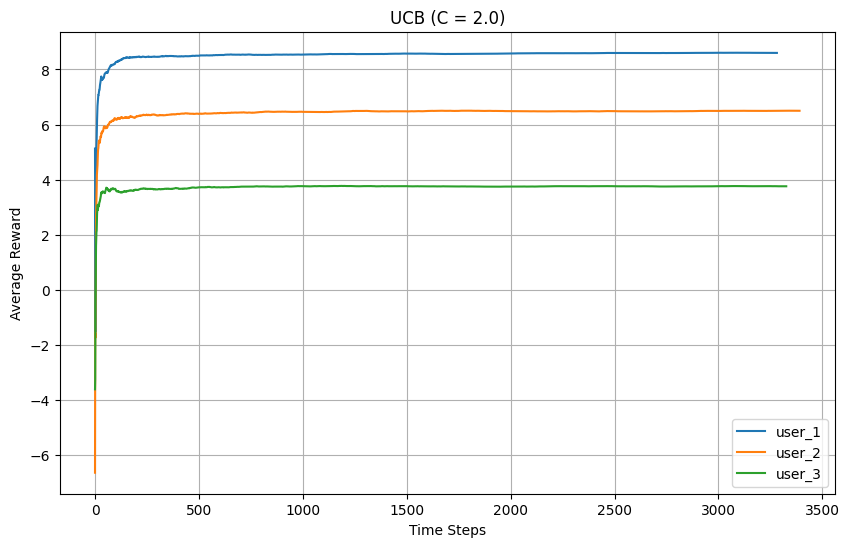

In [54]:
C_values = [0.5, 1.0, 2.0]
ucb_results = {}

for C in C_values:
    rewards, _ = run_ucb(C)
    ucb_results[C] = rewards

for C in C_values:
    plot_avg_reward(
        ucb_results[C],
        title=f"UCB (C = {C})"
    )

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [55]:
def softmax_select(bandit, tau=1.0):
    values = bandit["values"]
    
    # Numerical stability
    max_val = np.max(values)
    exp_values = np.exp((values - max_val) / tau)
    
    probabilities = exp_values / np.sum(exp_values)
    
    return np.random.choice(len(values), p=probabilities)

In [56]:
def run_softmax(tau=1.0, T=10000):
    bandits = {user: initialize_bandit() for user in USER_CLASSES}
    rewards_over_time = {user: [] for user in USER_CLASSES}
    
    for t in range(T):
        # Sample user context
        user_context = random.choice(USER_CLASSES)
        bandit = bandits[user_context]
        
        # Select arm via SoftMax
        arm_local = softmax_select(bandit, tau)
        
        # Global arm index
        arm_global = USER_CLASSES.index(user_context) * NUM_ARMS_PER_CONTEXT + arm_local
        
        # Sample reward
        reward = reward_sampler.sample(arm_global)
        
        # Update estimates
        update_estimates(bandit, arm_local, reward)
        
        # Log reward
        rewards_over_time[user_context].append(reward)
    
    return rewards_over_time, bandits

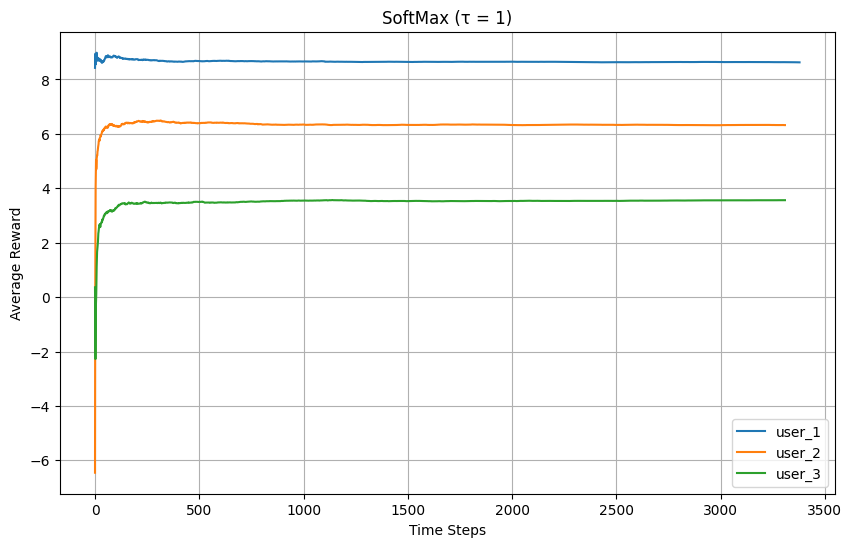

In [57]:
softmax_rewards, softmax_bandits = run_softmax(tau=1.0)

plot_avg_reward(
    softmax_rewards,
    title="SoftMax (τ = 1)"
)

## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [58]:
# Load test users and news articles
test_users = pd.read_csv("data/test_users.csv")
news_df = pd.read_csv("data/news_articles.csv")

print(test_users.head())
print(news_df.head())

  user_id   age  income  clicks  purchase_amount  session_duration  \
0   U4058  36.0   10000       4           500.00              2.54   
1   U1118  33.0   19607       8          1906.81             39.74   
2   U6555  51.0   21049      11           500.00             46.07   
3   U9170  58.0   25752      13           500.00             60.86   
4   U3348  32.0   25302      12          2693.22             39.77   

   content_variety  engagement_score  num_transactions  avg_monthly_spend  \
0          0.47162          49.32668                 8             229.80   
1          0.55219          56.42526                 4             819.43   
2          0.69961          58.88307                 5             113.35   
3          0.86843          86.15690                 8             237.13   
4          0.81805          84.82418                 5            1491.56   

   ...  loyalty_index  screen_brightness  battery_percentage  \
0  ...           13.0                3.0            

In [71]:
# Categorical columns used during training
cat_cols = ["browser_version", "region_code", "subscriber"]

CATEGORY_MAP = {
    "Entertainment": ["COMEDY", "PARENTING"],
    "Education": ["EDUCATION", "COLLEGE"],
    "Tech": ["TECH", "SCIENCE"],
    "Crime": ["CRIME", "U.S. NEWS"]
}

In [72]:
def safe_label_transform(encoder, value):
    """
    Safely transform a value using a fitted LabelEncoder.
    Unseen values are mapped to -1.
    """
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    else:
        return -1

In [73]:
def predict_user_context(user_row):
    X = user_row.drop("user_id").copy()
    
    # Handle missing age (same strategy as training)
    if pd.isna(X["age"]):
        X["age"] = train_users["age"].median()
    
    # Encode categorical columns safely
    for col in cat_cols:
        X[col] = safe_label_transform(feature_encoders[col], X[col])
    
    X = X.values.reshape(1, -1)
    pred = clf.predict(X)[0]
    
    return label_encoder.inverse_transform([pred])[0]

In [74]:
def select_best_category(bandits, user_context):
    context_bandit = bandits[user_context]
    best_arm = np.argmax(context_bandit["values"])
    return NEWS_CATEGORIES[best_arm]

def sample_article(news_df, bandit_category):
    # Get dataset categories mapped to this bandit category
    dataset_categories = CATEGORY_MAP.get(bandit_category, [])
    
    # Filter articles
    articles = news_df[news_df["category"].isin(dataset_categories)]
    
    # Fallback if no matching articles
    if articles.empty:
        articles = news_df
    
    return articles.sample(1).iloc[0]

def recommend_article(user_row, bandits):
    user_context = predict_user_context(user_row)
    category = select_best_category(bandits, user_context)
    article = sample_article(news_df, category)
    
    return {
        "predicted_user_context": user_context,
        "recommended_category": category,
        "article_id": article.get("article_id", None),
        "article_title": article.get("title", None)
    }

In [75]:
# Use UCB bandits with C = 1.0
_, ucb_bandits_best = run_ucb(C=1.0)

# Recommend for first 5 test users
for i in range(5):
    result = recommend_article(test_users.iloc[i], ucb_bandits_best)
    print(result)

{'predicted_user_context': 'user_3', 'recommended_category': 'Tech', 'article_id': None, 'article_title': None}
{'predicted_user_context': 'user_1', 'recommended_category': 'Crime', 'article_id': None, 'article_title': None}
{'predicted_user_context': 'user_2', 'recommended_category': 'Crime', 'article_id': None, 'article_title': None}
{'predicted_user_context': 'user_1', 'recommended_category': 'Crime', 'article_id': None, 'article_title': None}
{'predicted_user_context': 'user_1', 'recommended_category': 'Crime', 'article_id': None, 'article_title': None}


c:\Users\LENOVO\anaconda3\envs\rlcmab\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\rlcmab\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\rlcmab\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\rlcmab\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\rlcmab\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegressi

The recommendation engine integrates the trained user classifier with the
contextual bandit policy. For each user from the test set, the system predicts
the user context, selects the optimal news category using the learned bandit
policy, and samples a relevant news article. Due to differences between the
abstract bandit categories and the real dataset labels, a semantic mapping and
fallback strategy is used to ensure robustness.

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


### Average Reward vs Time
The plots illustrate how each algorithm learns over time across different user
contexts. UCB generally shows faster and more stable convergence, while
epsilon-greedy exhibits higher variance depending on ε. SoftMax demonstrates
smooth but slightly slower convergence due to probabilistic action selection.

### Hyperparameter Comparisons
Different values of ε (for epsilon-greedy) and C (for UCB) significantly affect
performance. Higher values promote exploration but delay convergence, whereas
lower values favor exploitation and faster stabilization.

### Observations and Discussion
Overall, context-aware bandit strategies outperform naive approaches by adapting
recommendations to user type. Among all methods, UCB provides the most consistent
performance across contexts.

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


### Comparison of Epsilon-Greedy, UCB, and SoftMax
Epsilon-greedy is simple and effective with careful tuning but lacks adaptive
exploration. UCB explicitly balances exploration and exploitation using
confidence bounds and consistently achieves higher rewards. SoftMax provides
smooth probabilistic exploration but may converge more slowly.

### Effect of Hyperparameters
The choice of ε and C plays a critical role in learning dynamics. Improper tuning
can lead to excessive exploration or premature exploitation, highlighting the
importance of hyperparameter selection.

### Strengths and Limitations
While epsilon-greedy is computationally lightweight, UCB offers more principled
exploration. SoftMax is stable but sensitive to temperature selection.